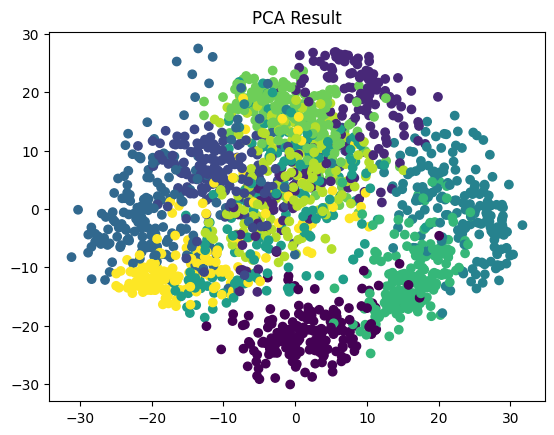

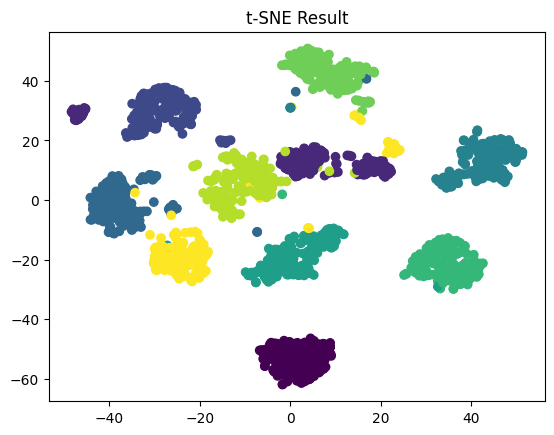

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1526 
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0787
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0643
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0556
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0461
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0390
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0348
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0315
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0294
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0277
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0266
Epoch 12/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0255
Epoch 13/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0245
Epoch 14/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0236
Epoch 15/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0227
Epoch 16/20
57/57 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

data = load_digits()
X = data.data
y = data.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA Result")
plt.show()

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure()
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)
plt.title("t-SNE Result")
plt.show()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)

decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X_scaled, X_scaled,
                epochs=20,
                batch_size=32,
                shuffle=True)

reconstructed = autoencoder.predict(X_scaled)

mse = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

threshold = np.mean(mse) + 2*np.std(mse)

anomalies = mse > threshold

print("Total Anomalies Detected:", np.sum(anomalies))